# Phase 2.2: Analisis Statistik Per Kelas Emosi

**Tujuan:**  
Menganalisis dan memvisualisasikan distribusi metrik konektivitas EEG
berdasarkan **tiga kelas emosi** (*negative, neutral, positive*) secara agregat
(bukan per individu). Analisis ini menghasilkan:
1. **Tabel deskriptif** — Mean, Std, Median, IQR per metrik per emosi
2. **Tabel ringkas Mean ± Std** — format laporan siap tulis
3. **Box Plot** — distribusi dan outlier per emosi
4. **Violin Plot** — distribusi penuh (density) per emosi
5. **Side-by-side Box Plot** — perbandingan antar metode (GC vs PDC bands)

---

In [1]:
# ============================================================
# SEL INI: IMPORT LIBRARY & KONFIGURASI GLOBAL
# ------------------------------------------------------------
# Sel ini memuat semua library (pandas, seaborn, matplotlib),
# mendefinisikan path folder input dan output, memuat 7 CSV
# dari Phase 1 (GC + 6 band PDC), dan melakukan strip prefiks
# kolom agar nama metrik menjadi generik.
#
# PENTING — Konvensi kolom:
#   CLASS_COL = 'class_label'  -> teks emosi ('negative'/'neutral'/'positive')
#                                 WAJIB dipakai untuk filter & plot
#   'class'                    -> angka (0/1/2), hanya untuk ML classifier
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'

# === PATH ===
PHASE1_DIR = Path(r'D:\Skripsi\new_data\phase_1_data_structuring\csv')
OUTPUT_DIR = Path(r'D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\output')
FIG_DIR    = Path(r'D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# === KONVENSI KOLOM ===
# FIX: Gunakan CLASS_COL = 'class_label' untuk semua filter & plotting
#      'class' berisi angka (0/1/2), BUKAN teks emosi
CLASS_COL = 'class_label'
EMOTIONS  = ['negative', 'neutral', 'positive']
PALETTE   = {'negative': '#e74c3c', 'neutral': '#3498db', 'positive': '#2ecc71'}

MEAN_COLS = [
    'mean_out_degree', 'mean_in_degree', 'mean_total_degree',
    'mean_out_strength', 'mean_in_strength', 'mean_total_strength',
]
SHORT = {
    'mean_out_degree'    : 'Out Deg',
    'mean_in_degree'     : 'In Deg',
    'mean_total_degree'  : 'Total Deg',
    'mean_out_strength'  : 'Out Str',
    'mean_in_strength'   : 'In Str',
    'mean_total_strength': 'Total Str',
}

DATASETS = {
    'GC'           : PHASE1_DIR / 'cleaned_graph_metrics_gc.csv',
    'PDC Delta'    : PHASE1_DIR / 'cleaned_graph_metrics_pdc_delta.csv',
    'PDC Theta'    : PHASE1_DIR / 'cleaned_graph_metrics_pdc_theta.csv',
    'PDC Alpha'    : PHASE1_DIR / 'cleaned_graph_metrics_pdc_alpha.csv',
    'PDC Beta'     : PHASE1_DIR / 'cleaned_graph_metrics_pdc_beta.csv',
    'PDC Gamma'    : PHASE1_DIR / 'cleaned_graph_metrics_pdc_gamma.csv',
    'PDC Broadband': PHASE1_DIR / 'cleaned_graph_metrics_pdc_broadband.csv',
}

# === LOAD & STRIP PREFIX ===
data = {}
for name, csv_path in DATASETS.items():
    if not csv_path.exists():
        print(f'  [SKIP] {name}: {csv_path}')
        continue
    df = pd.read_csv(csv_path)
    prefix = 'gc' if name == 'GC' else f"pdc_{name.lower().split()[-1]}"
    df = df.rename(columns={
        col: col.replace(f'{prefix}_', '', 1)
        for col in df.columns if col.startswith(f'{prefix}_')
    })
    data[name] = df
    print(f'  Loaded {name}: {df.shape} | {CLASS_COL}: {sorted(df[CLASS_COL].unique())}')

print(f'\nOutput : {OUTPUT_DIR}')
print(f'Figures: {FIG_DIR}')


  Loaded GC: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Delta: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Theta: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Alpha: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Beta: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Gamma: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Broadband: (675, 4047) | class_label: ['negative', 'neutral', 'positive']

Output : D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\output
Figures: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures


---
## 1. Tabel Deskriptif Per Kelas Emosi

Menghitung statistik deskriptif lengkap (Mean, Std, Median, Q1, Q3, IQR, Min, Max,
Skewness, Kurtosis) untuk setiap kombinasi **(kelas emosi × metrik)**.

In [2]:
# ============================================================
# SEL INI: TABEL DESKRIPTIF LENGKAP PER KELAS
# ------------------------------------------------------------
# Sel ini menghitung statistik deskriptif untuk setiap
# kombinasi (kelas emosi x metrik) pada semua 7 dataset.
# Statistik yang dihitung: n, mean, std, median, Q1, Q3,
# IQR, min, max, skewness, kurtosis.
#
# FIX: Filter emosi menggunakan CLASS_COL ('class_label'),
#      bukan 'class' (numerik 0/1/2) yang menghasilkan 0 baris.
# FIX: Tampilan pivot menggunakan pivot_table() (aman dari
#      error duplikasi) bukan pivot().
# Output: descriptive_stats_{method}.csv
# ============================================================
def compute_descriptive_table(df):
    rows = []
    for emotion in EMOTIONS:
        # FIX: filter dengan CLASS_COL ('class_label'), bukan 'class'
        subset = df[df[CLASS_COL] == emotion][MEAN_COLS]
        for col in MEAN_COLS:
            vals = subset[col].dropna()
            rows.append({
                'emotion': emotion,
                'metric' : SHORT[col],
                'n'      : len(vals),
                'mean'   : round(vals.mean(), 4),
                'std'    : round(vals.std(),  4),
                'median' : round(vals.median(), 4),
                'q1'     : round(vals.quantile(0.25), 4),
                'q3'     : round(vals.quantile(0.75), 4),
                'iqr'    : round(vals.quantile(0.75) - vals.quantile(0.25), 4),
                'min'    : round(vals.min(), 4),
                'max'    : round(vals.max(), 4),
                'skew'   : round(vals.skew(), 4),
                'kurtosis': round(vals.kurtosis(), 4),
            })
    return pd.DataFrame(rows)

all_desc = {}
for name, df in data.items():
    desc = compute_descriptive_table(df)
    all_desc[name] = desc
    desc.to_csv(OUTPUT_DIR / f'descriptive_stats_{name.lower().replace(" ","_")}.csv', index=False)

    print(f'\n{"="*70}')
    print(f'  {name} - Descriptive Statistics')
    print(f'{"="*70}')
    # FIX: pivot_table untuk menghindari error duplikasi
    display_df = desc.pivot_table(
        index='metric', columns='emotion',
        values=['mean', 'std', 'median', 'iqr'], aggfunc='first'
    )[EMOTIONS] if False else desc.pivot_table(
        index='metric', columns='emotion',
        values=['mean', 'std', 'median', 'iqr']
    )
    # Urutkan kolom sesuai EMOTIONS
    col_order = [(stat, emo) for stat in ['mean', 'std', 'median', 'iqr'] for emo in EMOTIONS
                 if (stat, emo) in display_df.columns]
    display_df = display_df[col_order].round(4)
    print(display_df.to_string())
    print(f'  -> Saved: descriptive_stats_{name.lower().replace(" ","_")}.csv')



  GC - Descriptive Statistics
                mean                              std                           median                              iqr                      
emotion     negative    neutral   positive   negative    neutral   positive   negative    neutral   positive   negative    neutral   positive
metric                                                                                                                                       
In Deg        6.3365     6.3390     6.3388     3.3538     3.3914     3.3882     6.1129     6.1129     6.1129     0.0000     0.0000     0.0000
In Str     2114.2545  2239.6123  2499.9037   901.8650   920.4099   790.6783  1952.4567  2063.7065  2474.2160  1106.6387   946.2852   996.8020
Out Deg       6.3365     6.3390     6.3388     3.3538     3.3914     3.3882     6.1129     6.1129     6.1129     0.0000     0.0000     0.0000
Out Str    2114.2545  2239.6123  2499.9037   901.8650   920.4099   790.6783  1952.4567  2063.7065  2474.2160  1106.63

---
## 2. Tabel Ringkas Mean ± Std

Format ringkas siap laporan: satu baris per metrik, kolom = tiap emosi, isi = `mean ± std`.

In [3]:
# ============================================================
# SEL INI: TABEL RINGKAS MEAN ± STD (FORMAT LAPORAN)
# ------------------------------------------------------------
# Sel ini meringkas tabel deskriptif menjadi format yang lebih
# mudah dibaca dan siap dimasukkan ke Bab 4 skripsi.
# Format per sel: '9.4673 ± 0.1234'
# Satu baris = satu metrik, satu kolom = satu kelas emosi.
#
# FIX: Filter menggunakan kolom 'emotion' dari tabel deskriptif
#      yang sudah benar (bukan 'class' numerik).
# Output: summary_mean_std_{method}.csv
# ============================================================
for name, desc in all_desc.items():
    print(f'\n{"="*70}')
    print(f'  {name} — Mean ± Std')
    print(f'{"="*70}')

    rows = []
    for metric in [SHORT[c] for c in MEAN_COLS]:
        row = {'metric': metric}
        for emotion in EMOTIONS:
            # FIX: filter dari kolom 'emotion' (teks) di tabel deskriptif
            subset = desc[(desc['metric'] == metric) & (desc['emotion'] == emotion)]
            if subset.empty:
                row[f'{emotion}_formatted'] = 'N/A'
                continue
            m = subset['mean'].values[0]
            s = subset['std'].values[0]
            row[f'{emotion}_mean']      = m
            row[f'{emotion}_std']       = s
            row[f'{emotion}_formatted'] = f'{m:.4f} ± {s:.4f}'
        rows.append(row)

    summary = pd.DataFrame(rows)

    # Cetak tabel
    header = f'  {"Metric":<12}' + ''.join(f'  {e.capitalize():>25}' for e in EMOTIONS)
    print(header)
    print('  ' + '-' * 85)
    for _, row in summary.iterrows():
        line = f'  {row["metric"]:<12}'
        for emotion in EMOTIONS:
            line += f'  {row.get(f"{emotion}_formatted", "N/A"):>25}'
        print(line)

    summary.to_csv(OUTPUT_DIR / f'summary_mean_std_{name.lower().replace(" ","_")}.csv', index=False)
    print(f'  -> Saved: summary_mean_std_{name.lower().replace(" ","_")}.csv')



  GC — Mean ± Std
  Metric                         Negative                    Neutral                   Positive
  -------------------------------------------------------------------------------------
  Out Deg                 6.3365 ± 3.3538            6.3390 ± 3.3914            6.3388 ± 3.3882
  In Deg                  6.3365 ± 3.3538            6.3390 ± 3.3914            6.3388 ± 3.3882
  Total Deg              12.6730 ± 6.7075           12.6780 ± 6.7828           12.6776 ± 6.7763
  Out Str            2114.2545 ± 901.8650       2239.6123 ± 920.4099       2499.9037 ± 790.6783
  In Str             2114.2545 ± 901.8650       2239.6123 ± 920.4099       2499.9037 ± 790.6783
  Total Str         4228.5090 ± 1803.7300      4479.2247 ± 1840.8199      4999.8073 ± 1581.3565
  -> Saved: summary_mean_std_gc.csv

  PDC Delta — Mean ± Std
  Metric                         Negative                    Neutral                   Positive
  -------------------------------------------------------------

---
## 3. Box Plot Per Metrik (x: Emosi, y: Nilai Metrik)

Menampilkan distribusi, median, kuartil, dan outlier setiap metrik
berdasarkan kelas emosi. Diamond (◆) menandai nilai mean.


>>> GC
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\gc_boxplot.png


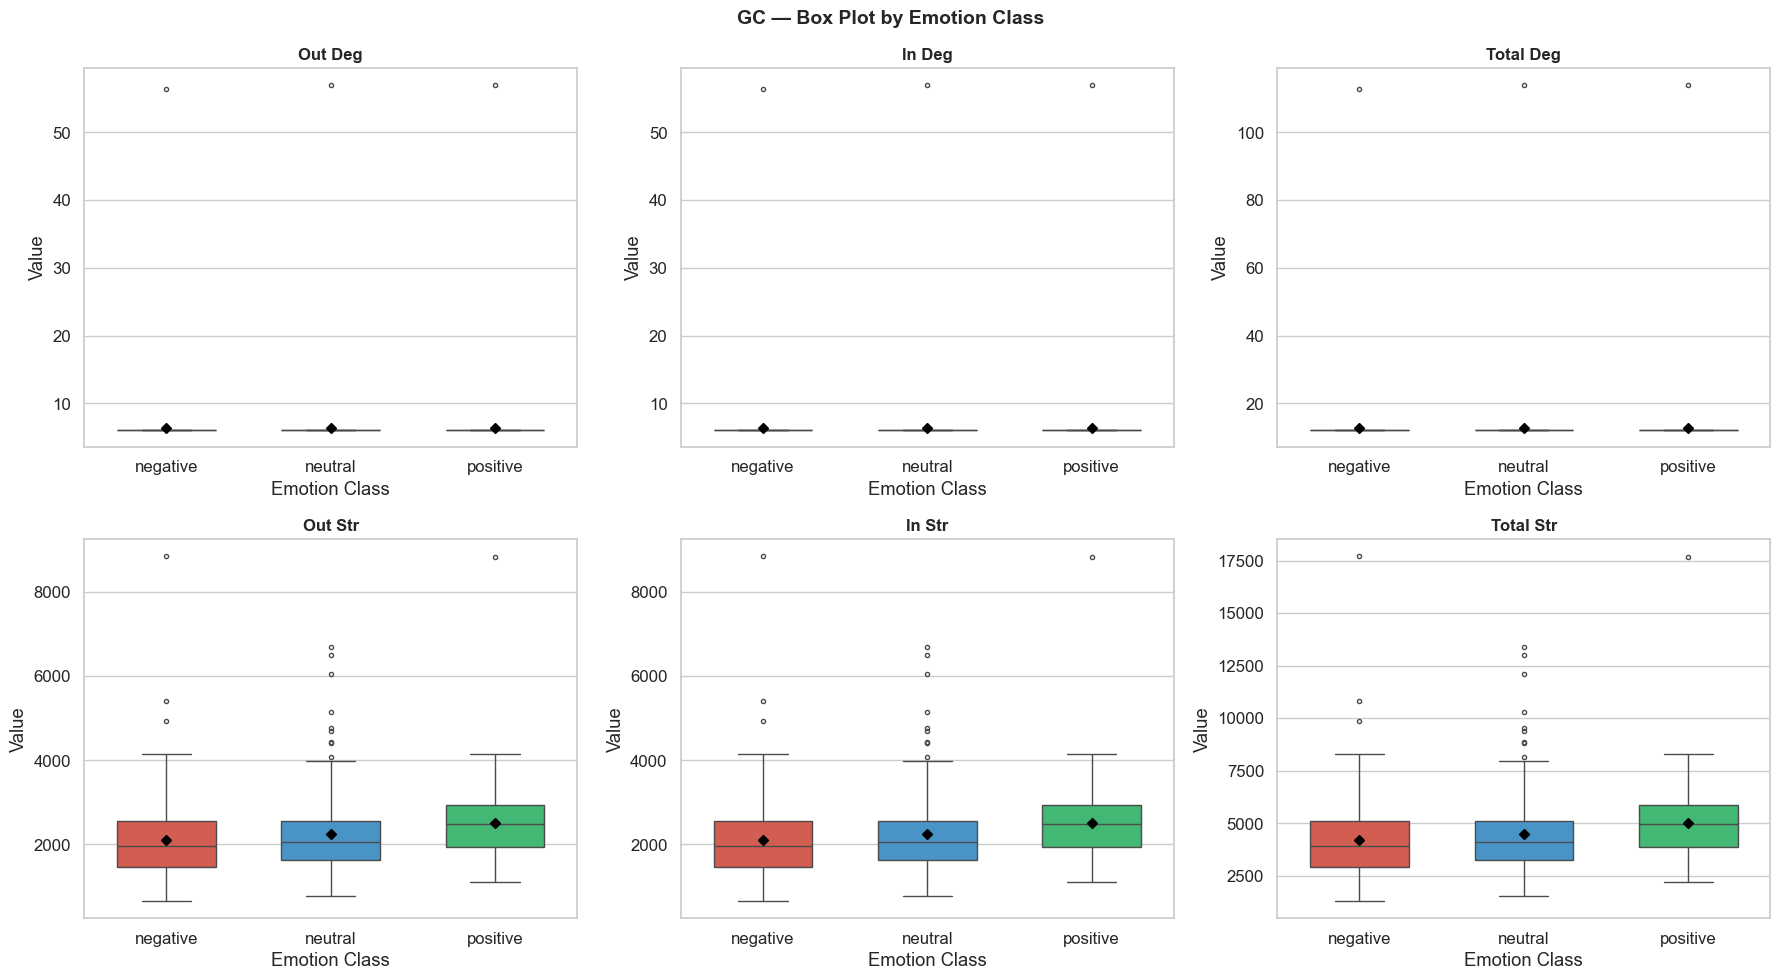


>>> PDC Delta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\pdc_delta_boxplot.png


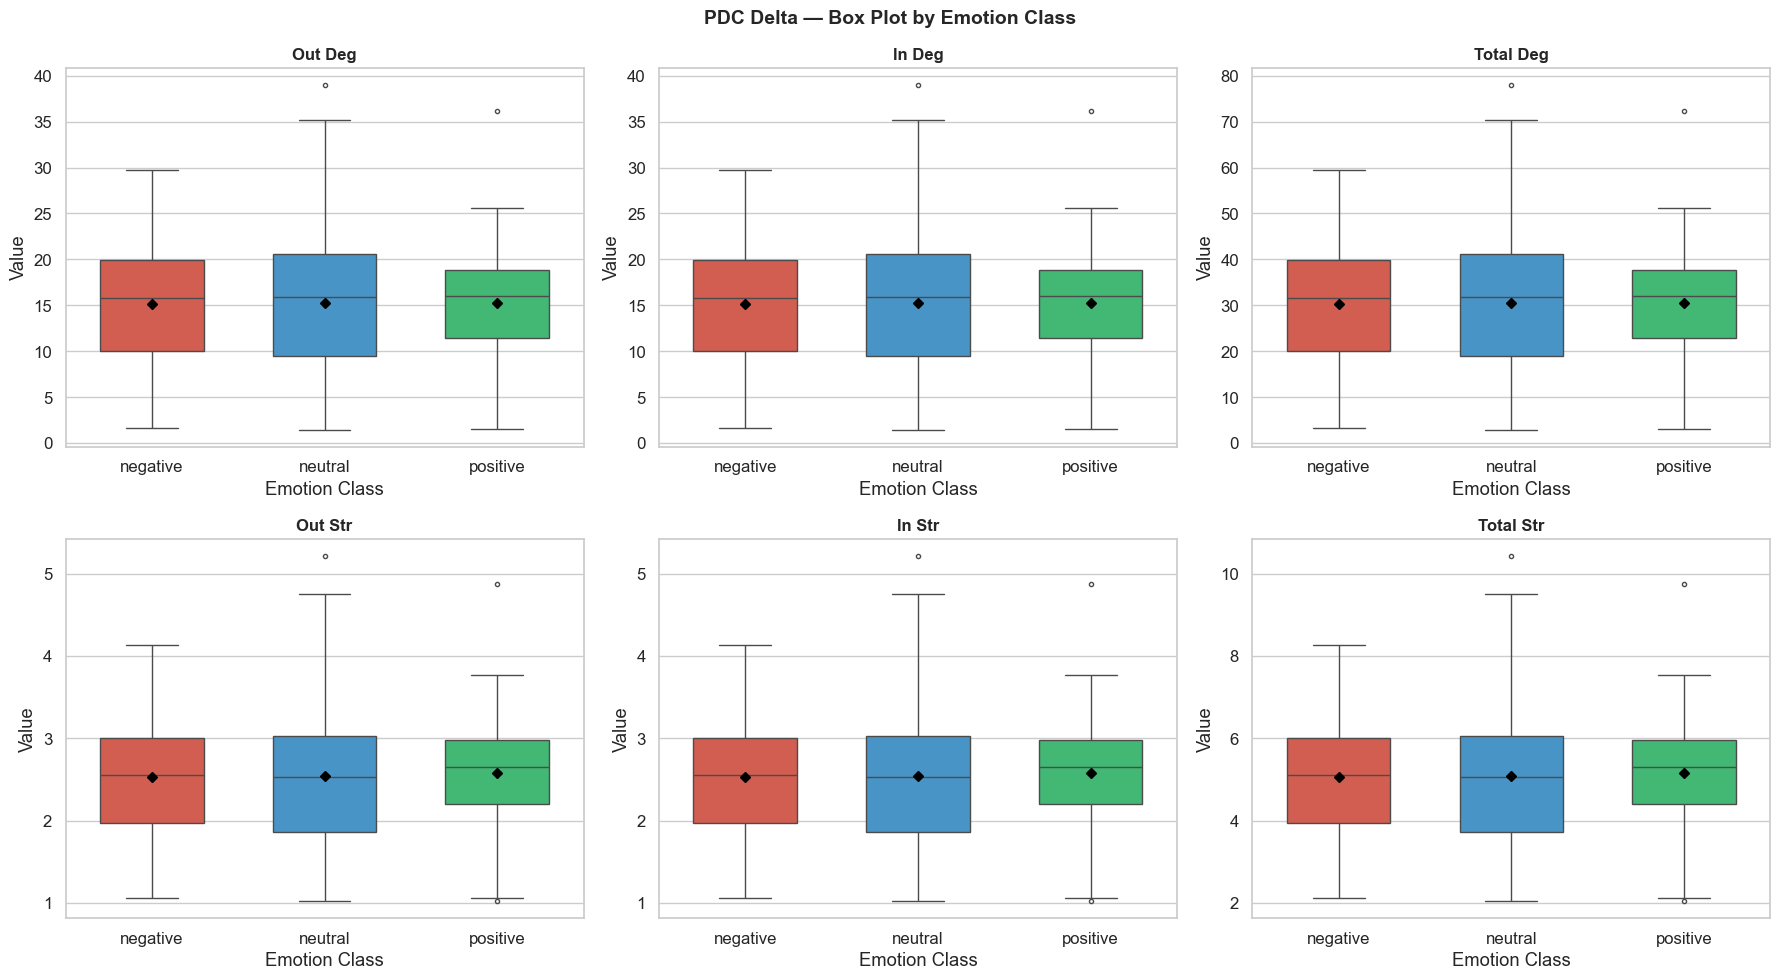


>>> PDC Theta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\pdc_theta_boxplot.png


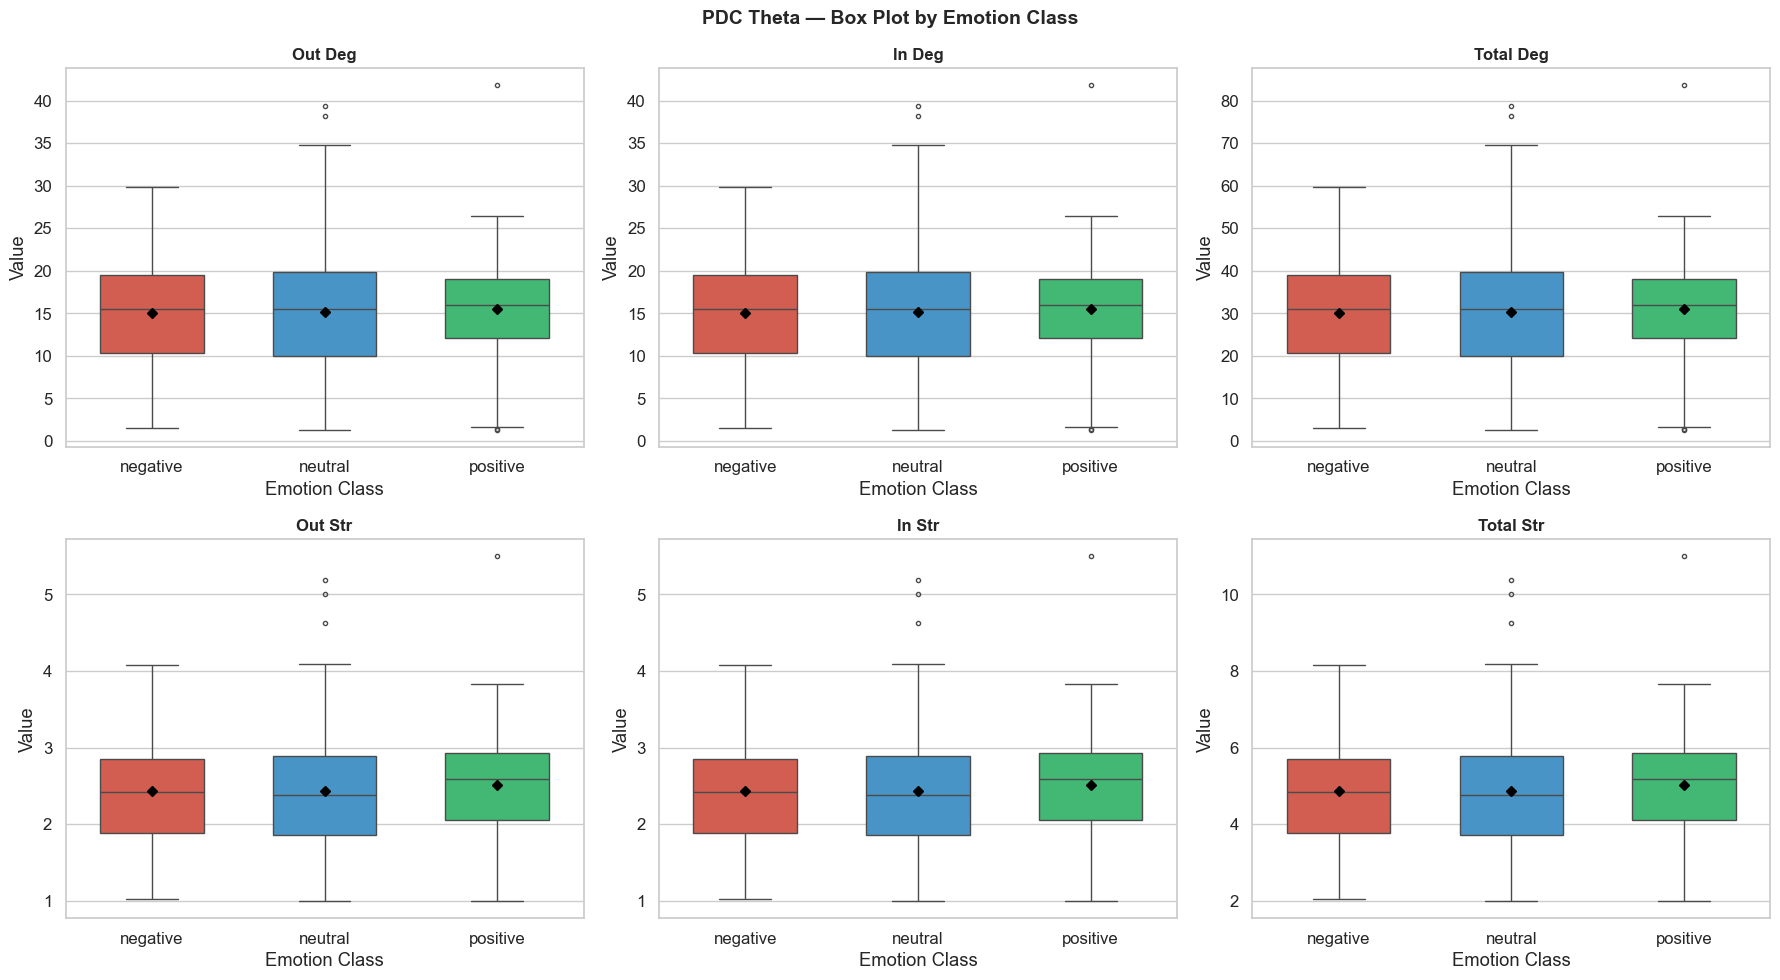


>>> PDC Alpha
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\pdc_alpha_boxplot.png


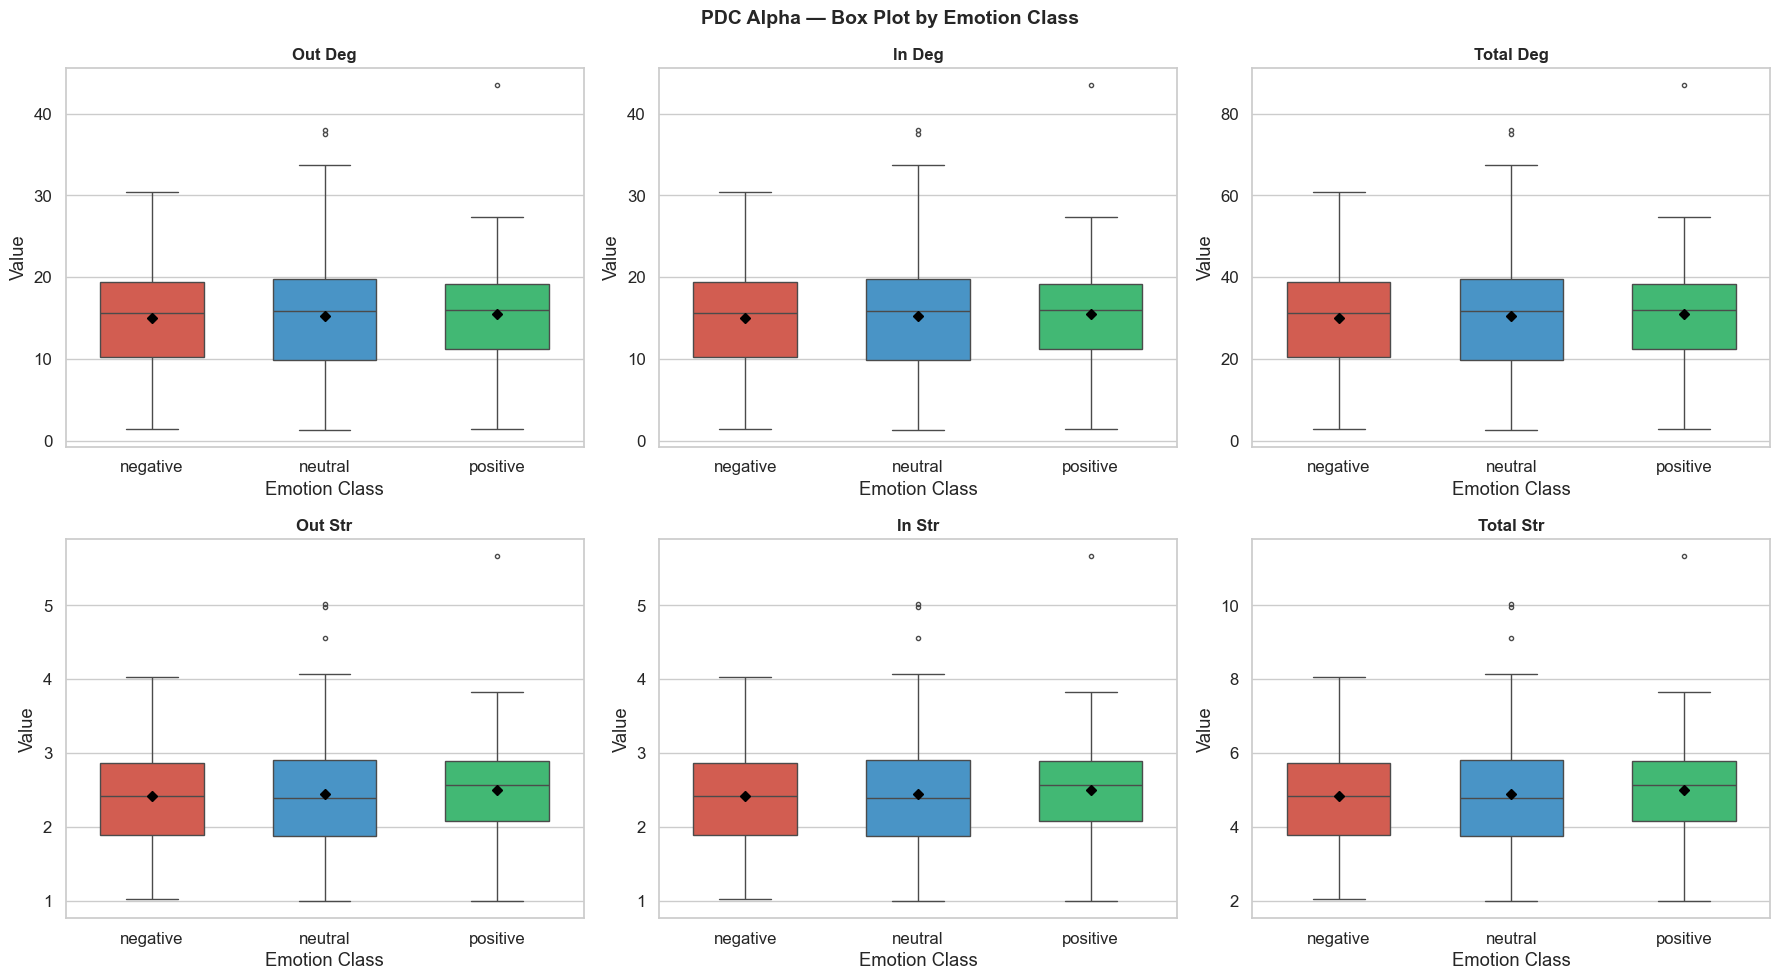


>>> PDC Beta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\pdc_beta_boxplot.png


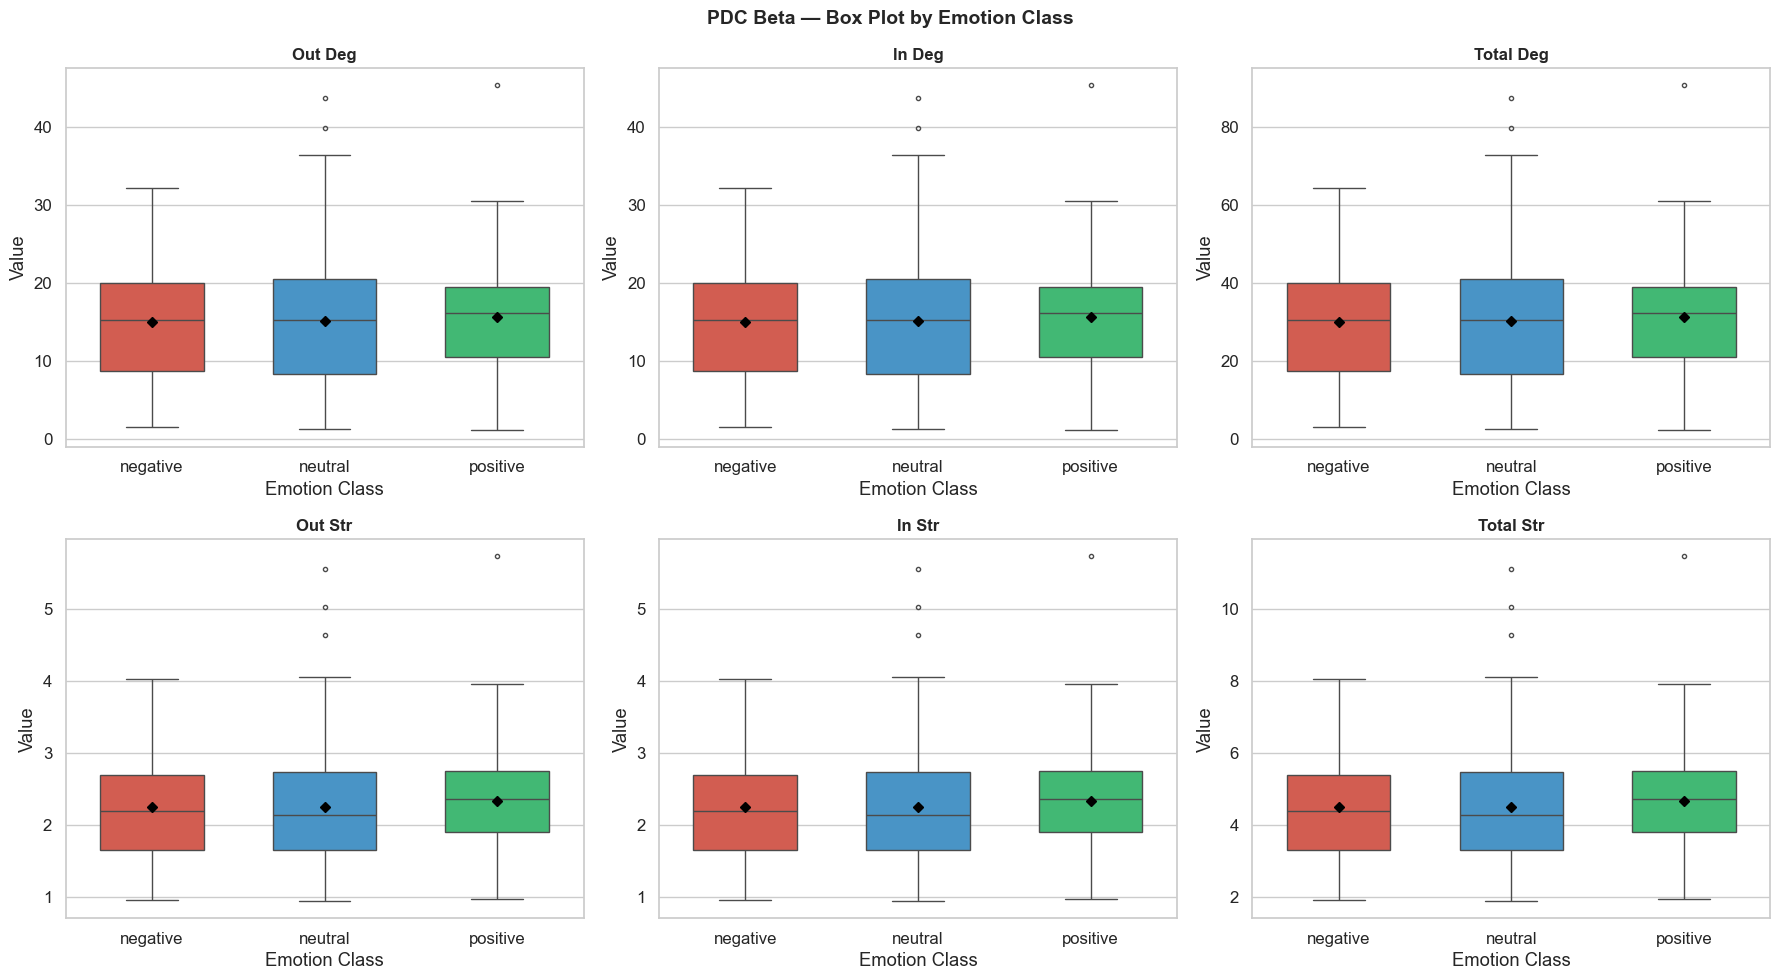


>>> PDC Gamma
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\pdc_gamma_boxplot.png


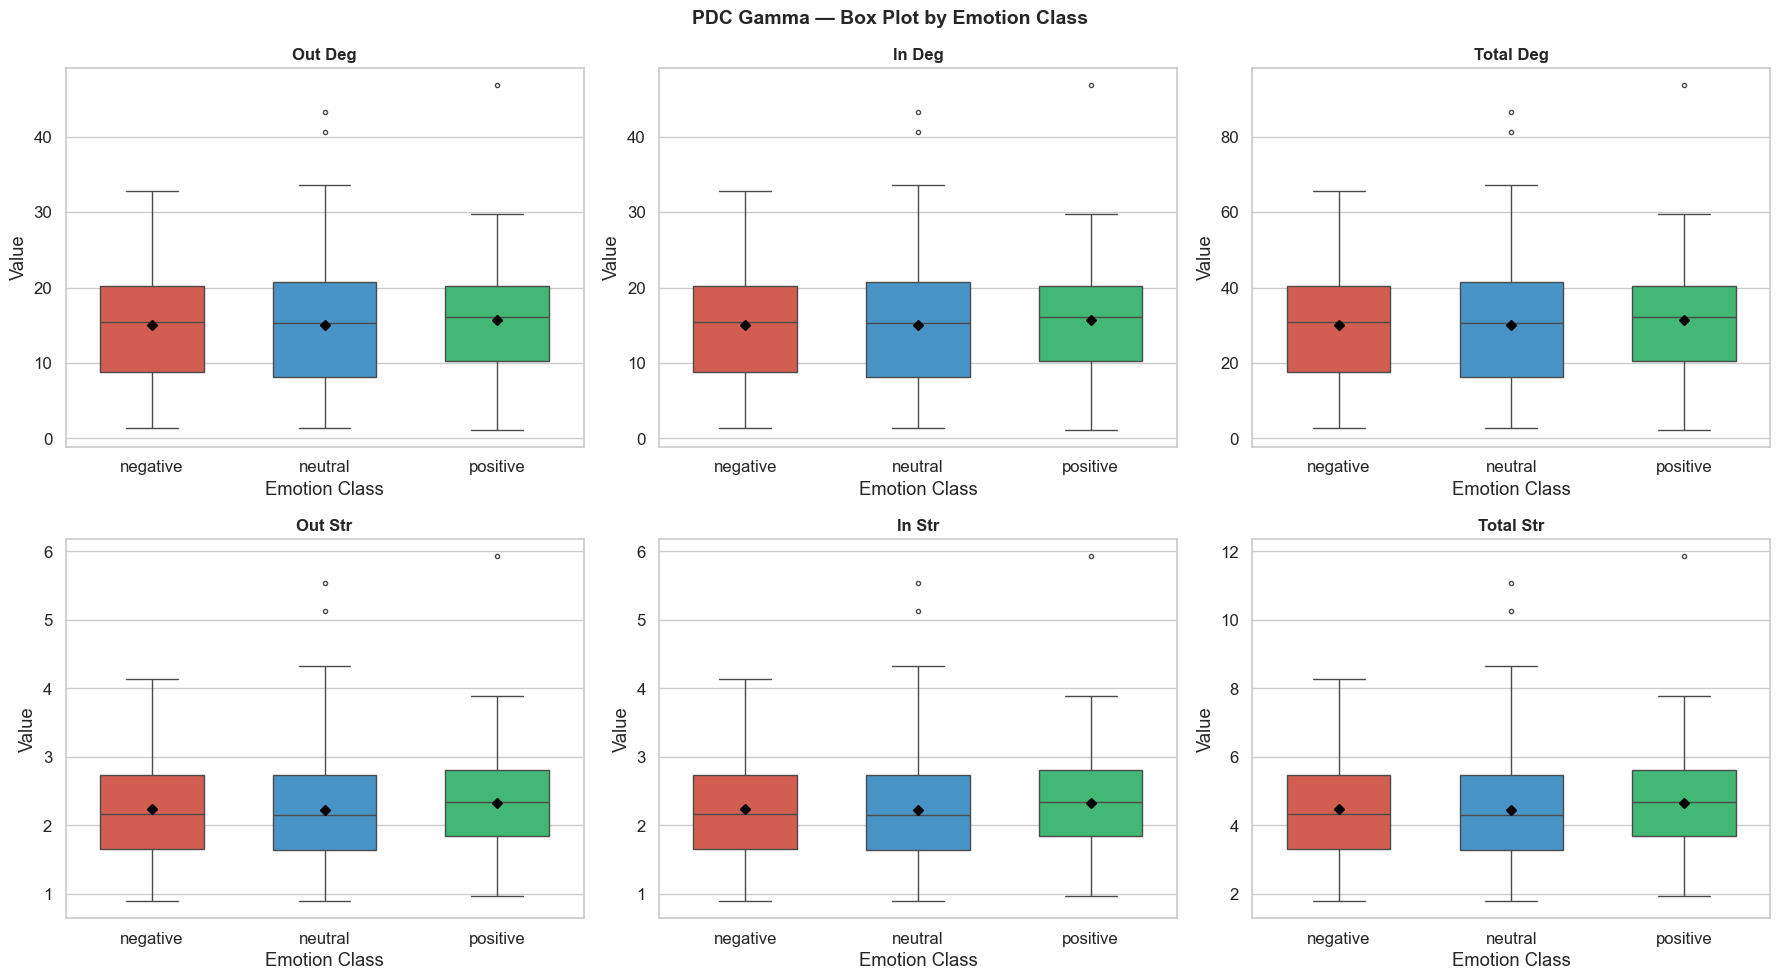


>>> PDC Broadband
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\pdc_broadband_boxplot.png


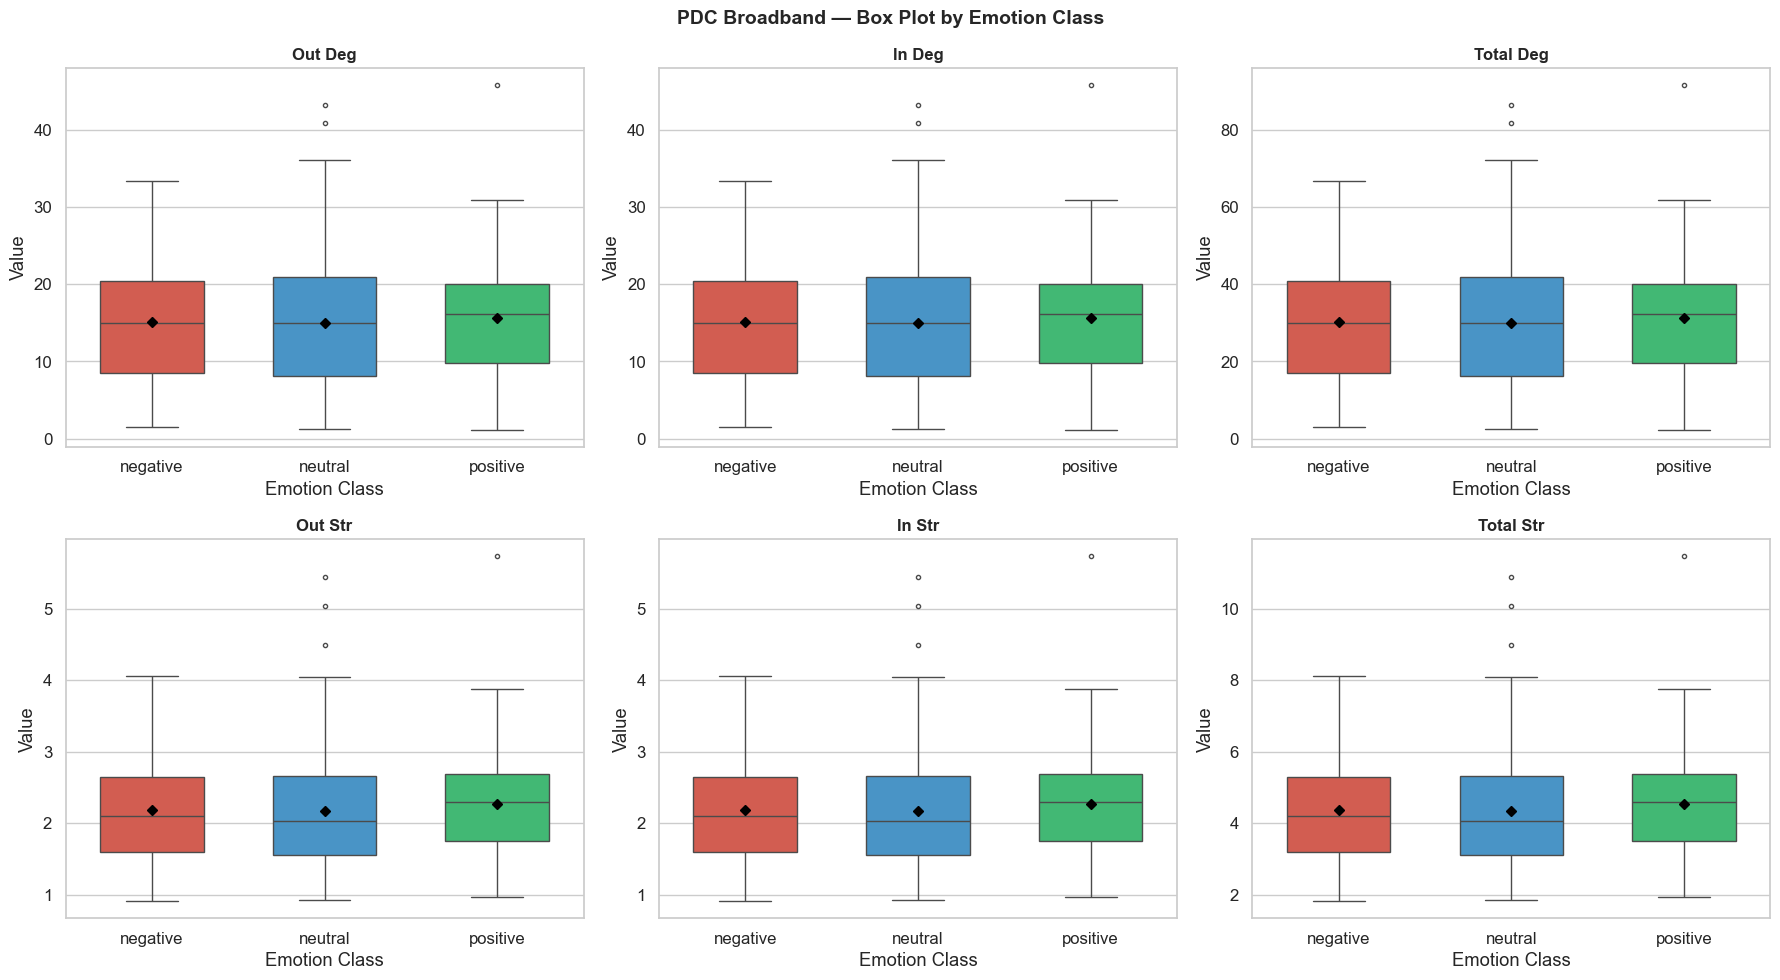

In [4]:
# ============================================================
# SEL INI: BOX PLOT PER METRIK (6 subplot, 3 emosi)
# ------------------------------------------------------------
# Sel ini membuat box plot untuk setiap metrik (6 subplot),
# dengan sumbu-X = 3 kelas emosi dan sumbu-Y = nilai metrik.
# Menampilkan median (garis tengah), Q1-Q3 (kotak), whisker,
# outlier (titik kecil), dan mean (tanda berlian ◆ hitam).
#
# FIX: x=CLASS_COL ('class_label') bukan x='class' (numerik).
#      Sebelumnya x='class' menyebabkan sumbu-X menampilkan
#      0/1/2 dan order EMOTIONS tidak cocok -> plot kosong.
# Output: {method}_boxplot.png
# ============================================================
def plot_boxplots(df, method_name, save_prefix):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, col in enumerate(MEAN_COLS):
        ax = axes[idx]
        # FIX: x=CLASS_COL ('class_label') agar x-axis = teks emosi
        sns.boxplot(
            data=df, x=CLASS_COL, y=col, ax=ax,
            order=EMOTIONS, palette=PALETTE,
            width=0.6, fliersize=3, showmeans=True,
            meanprops={'marker': 'D', 'markerfacecolor': 'black',
                       'markeredgecolor': 'black', 'markersize': 5},
        )
        ax.set_title(SHORT[col], fontsize=12, fontweight='bold')
        ax.set_xlabel('Emotion Class')
        ax.set_ylabel('Value')
        ax.tick_params(axis='x', rotation=0)

    fig.suptitle(f'{method_name} — Box Plot by Emotion Class',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    p = FIG_DIR / f'{save_prefix}_boxplot.png'
    fig.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {p}')
    plt.show()

for name, df in data.items():
    print(f'\n>>> {name}')
    plot_boxplots(df, name, name.lower().replace(' ', '_'))


---
## 4. Violin Plot Per Metrik (x: Emosi, y: Nilai Metrik)

Violin plot menampilkan distribusi penuh (*kernel density estimation*)
di samping quartile, sehingga bentuk distribusi data lebih terlihat jelas.


>>> GC
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\gc_violin.png


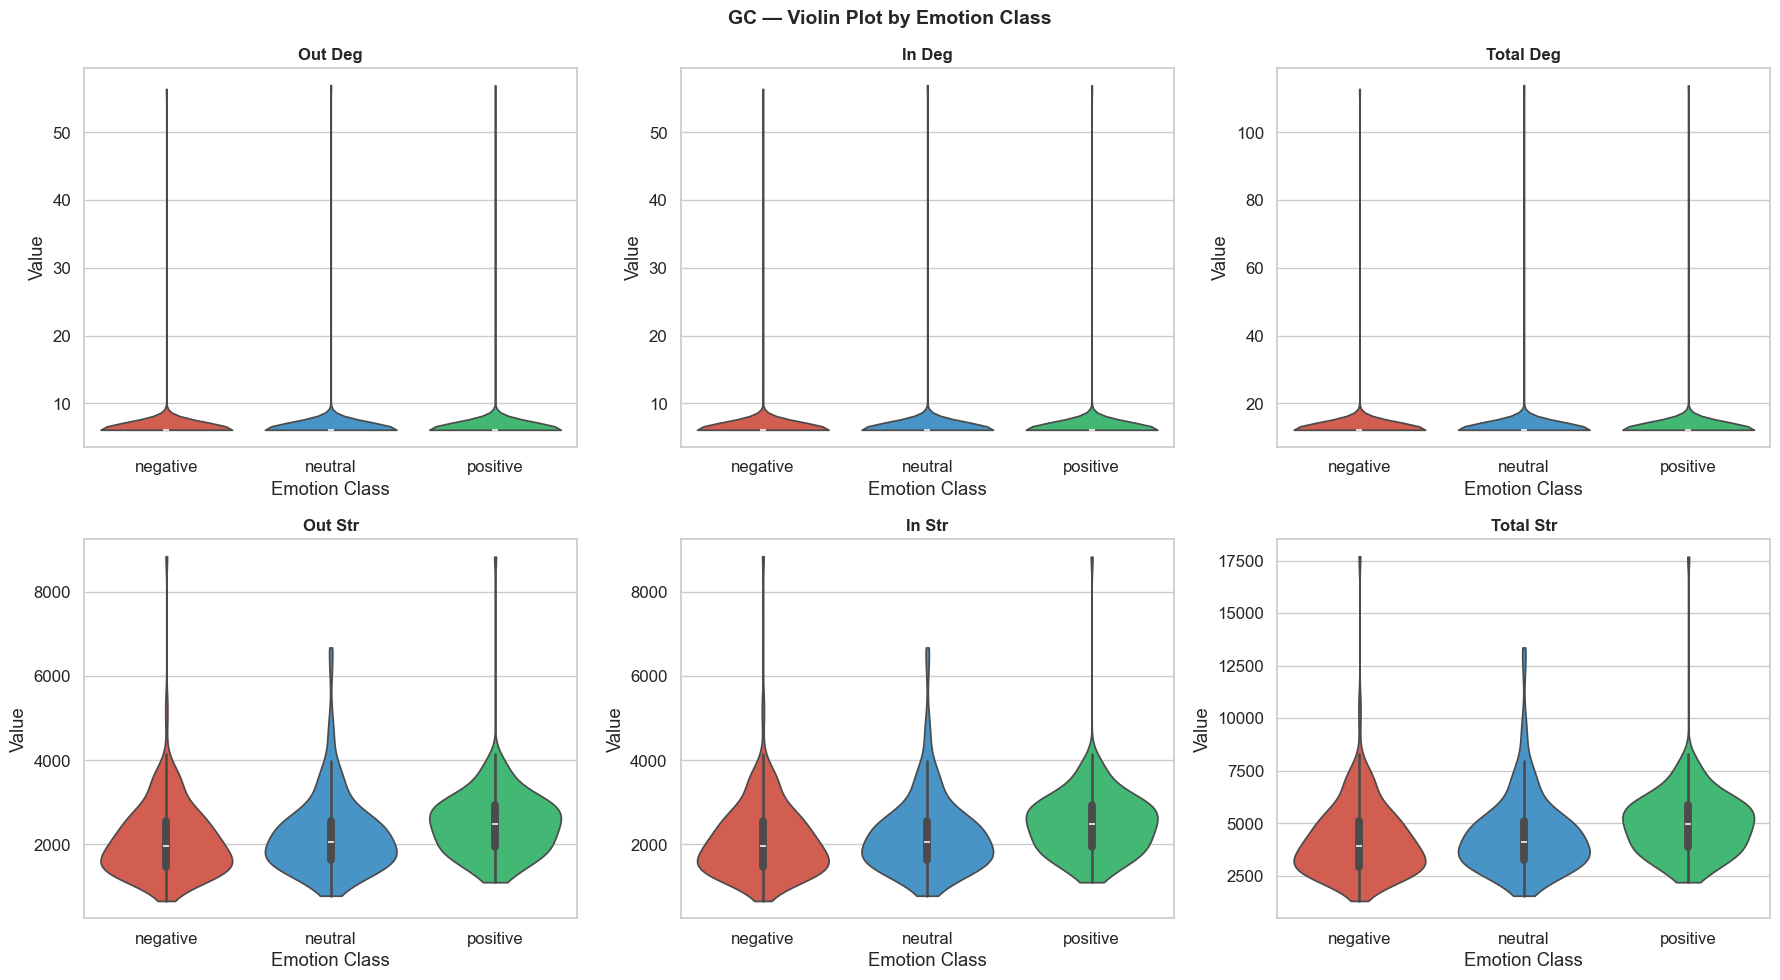


>>> PDC Delta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\pdc_delta_violin.png


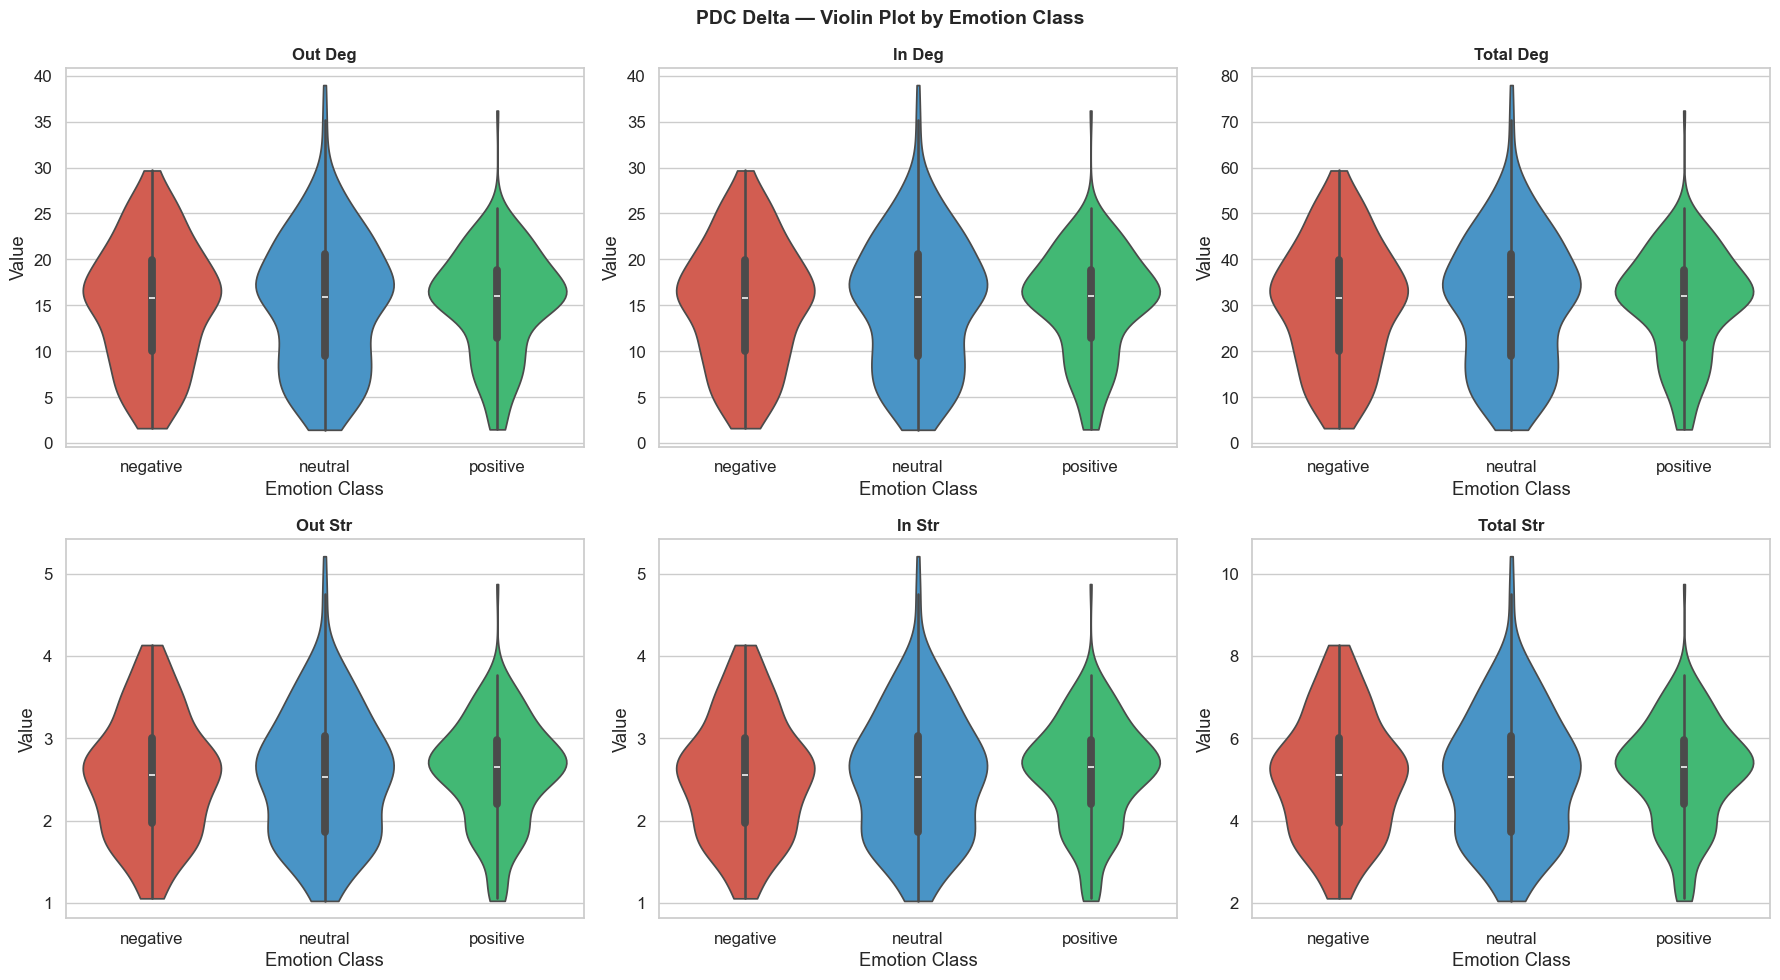


>>> PDC Theta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\pdc_theta_violin.png


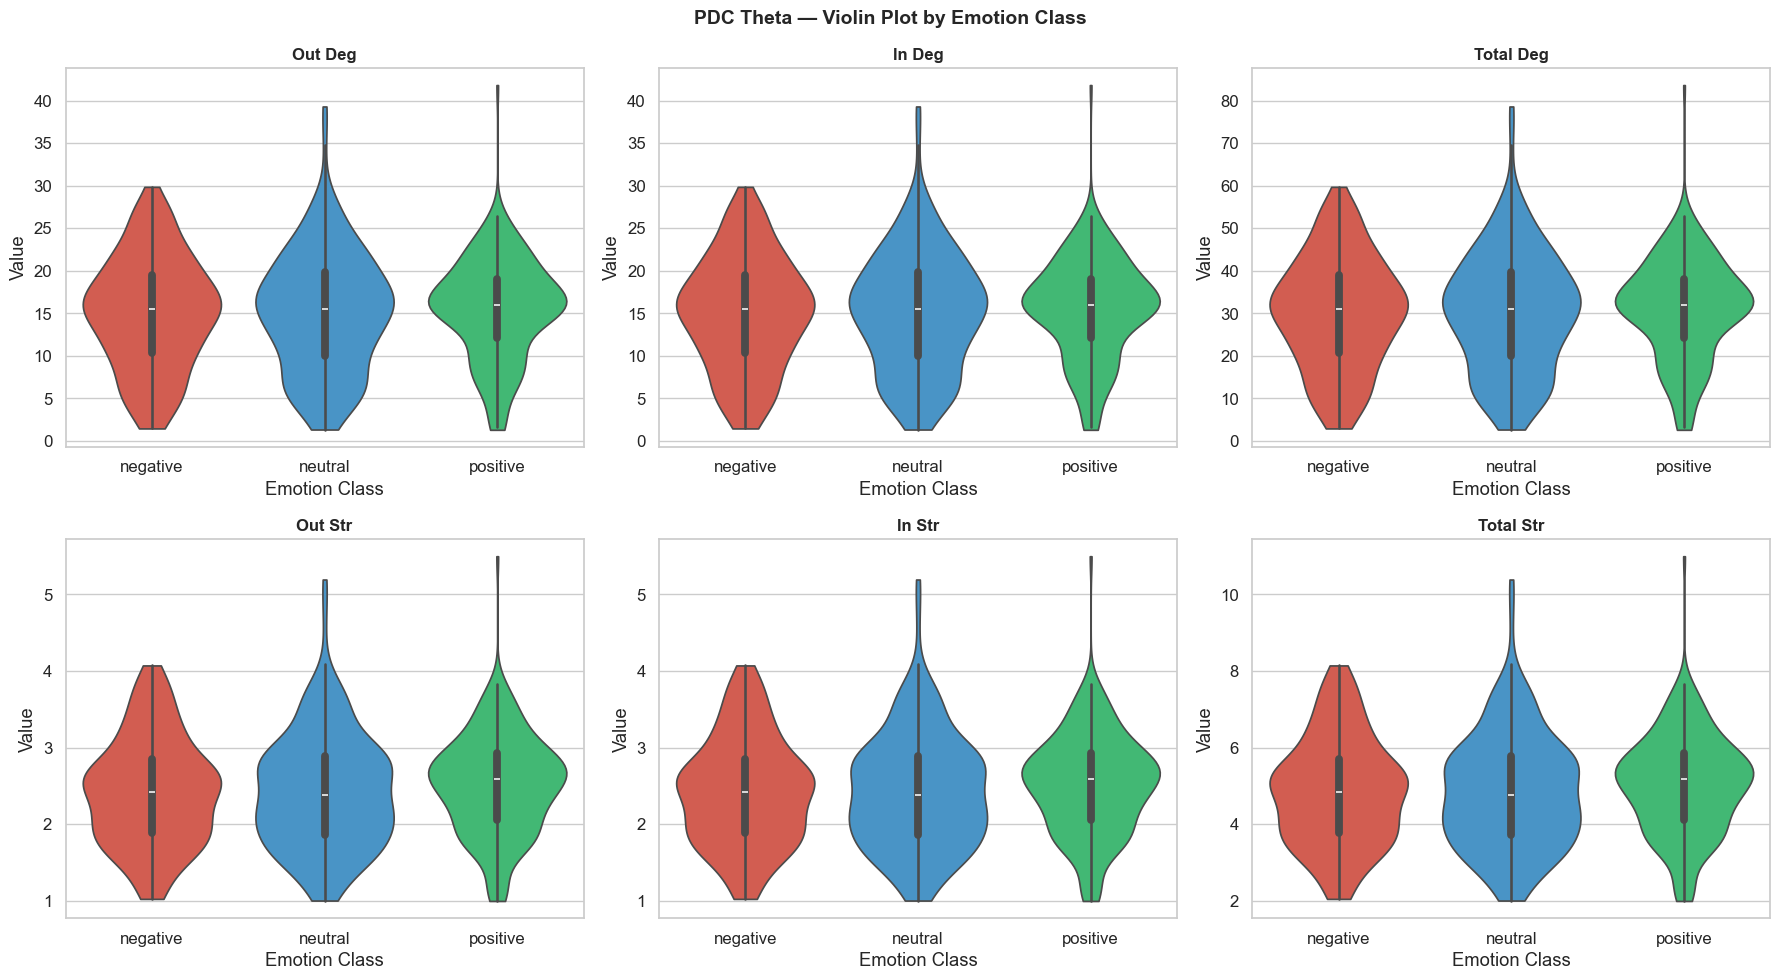


>>> PDC Alpha
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\pdc_alpha_violin.png


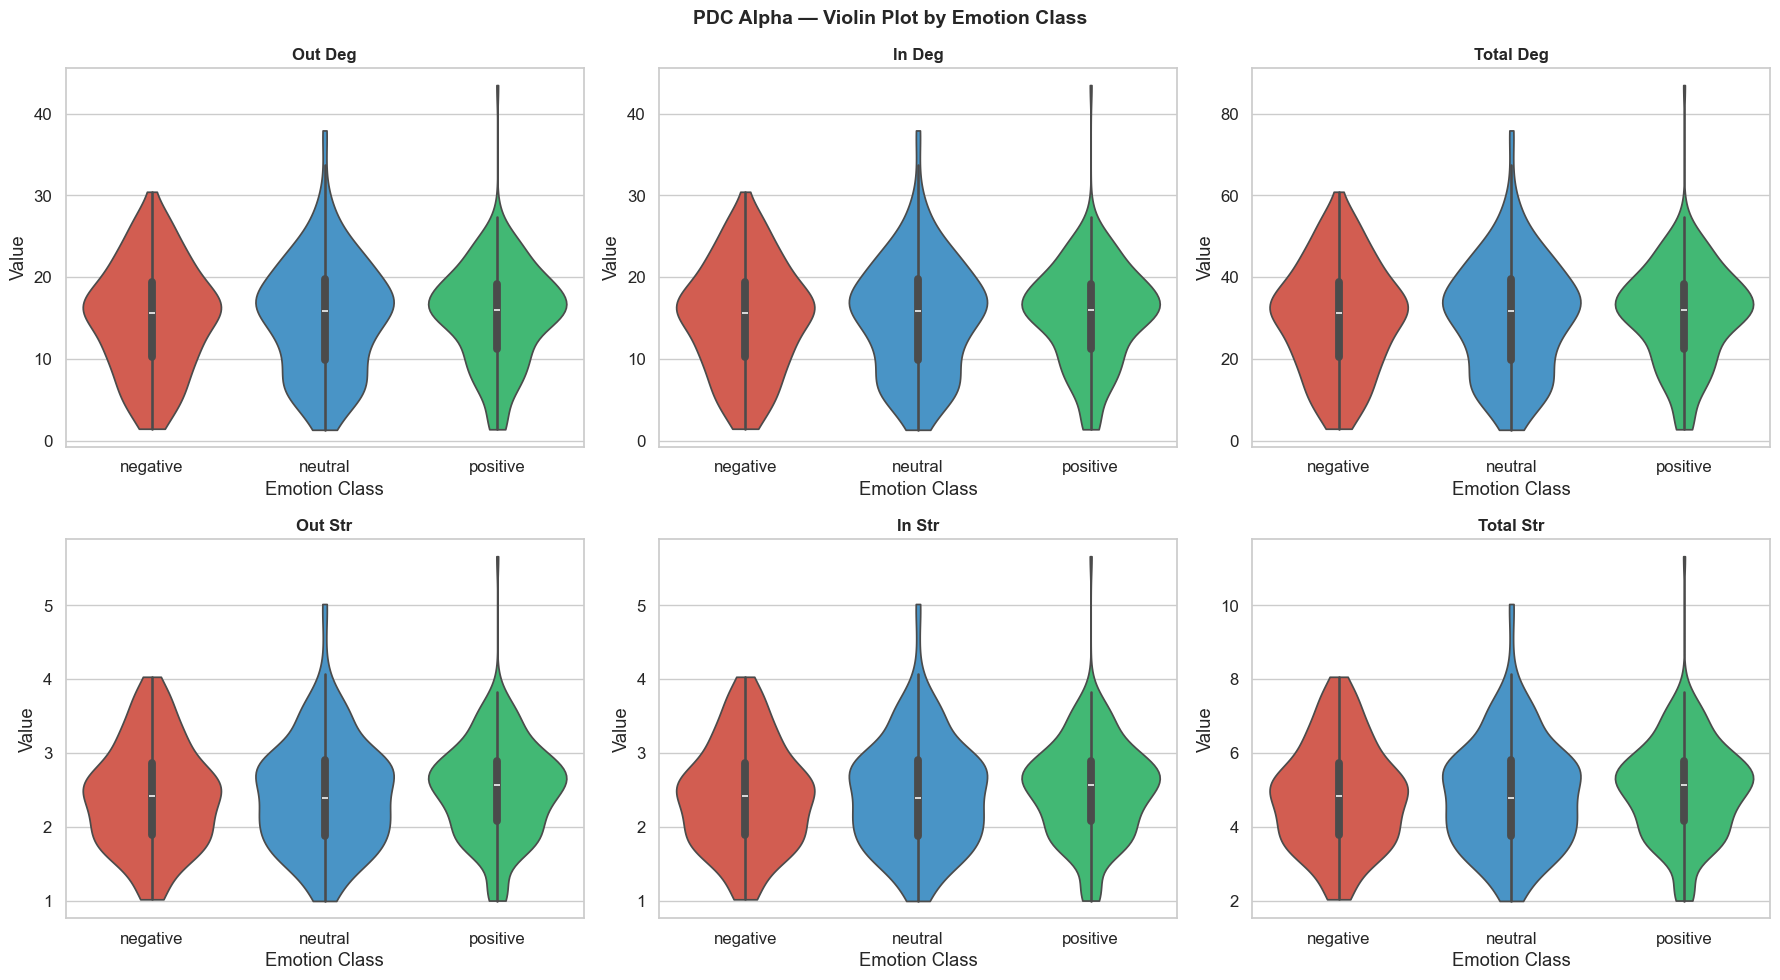


>>> PDC Beta
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\pdc_beta_violin.png


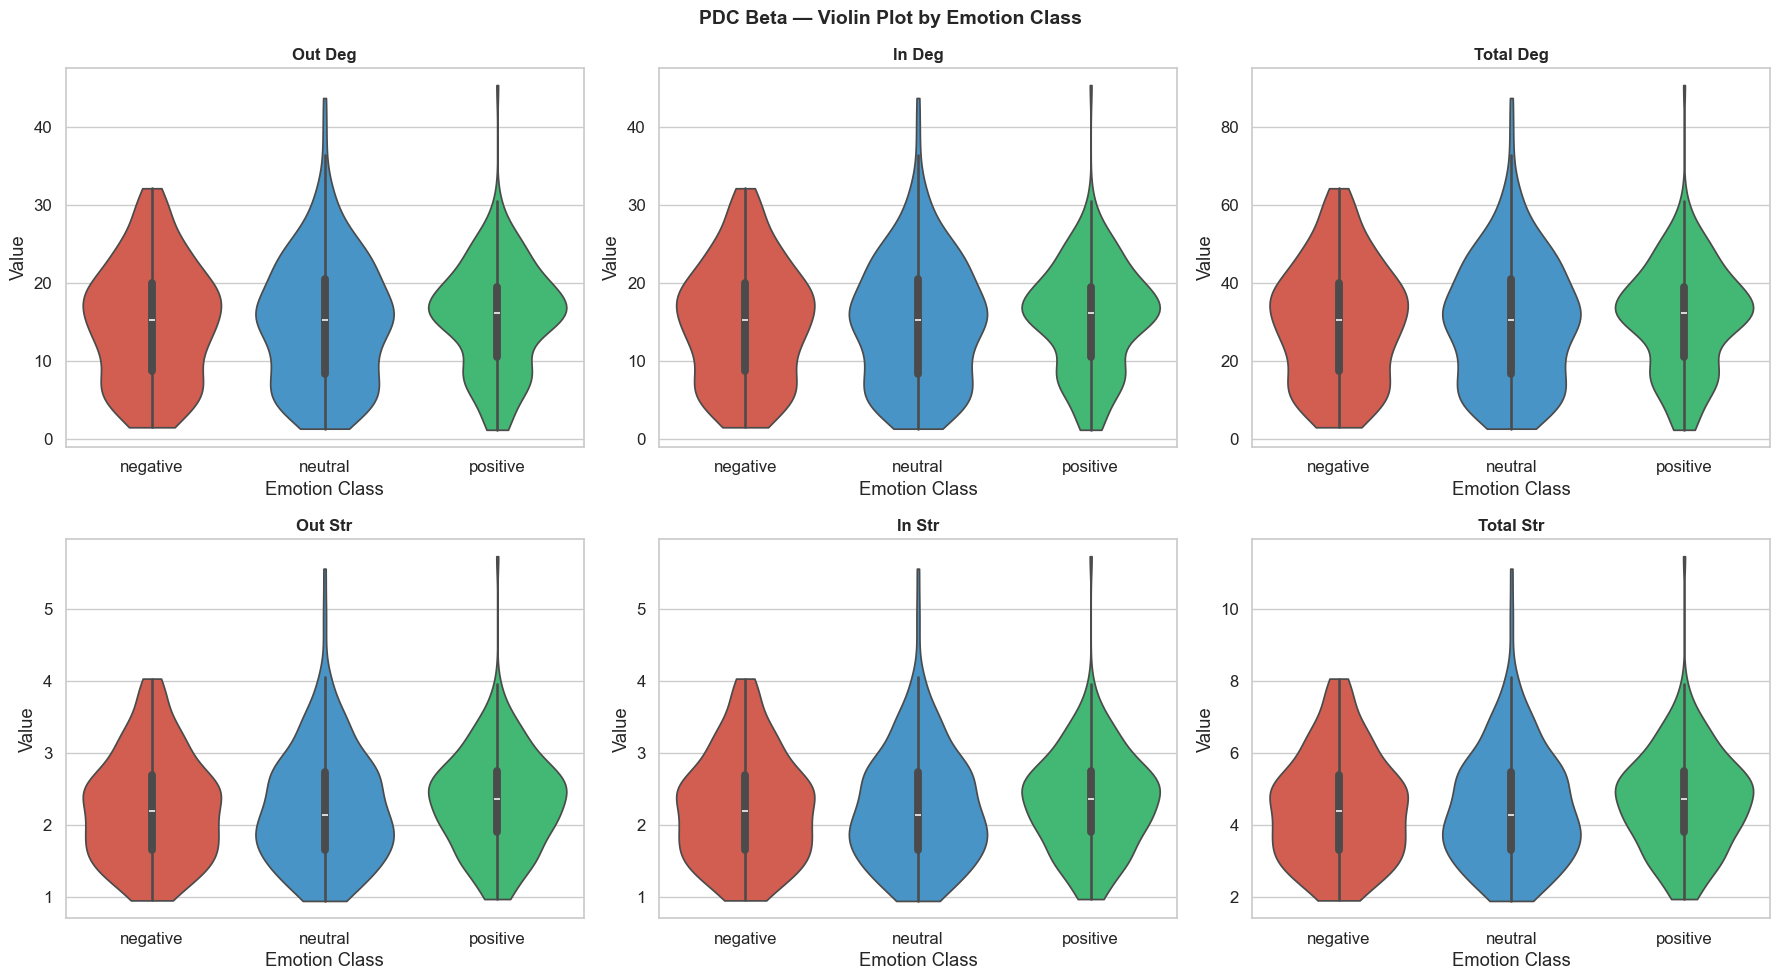


>>> PDC Gamma
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\pdc_gamma_violin.png


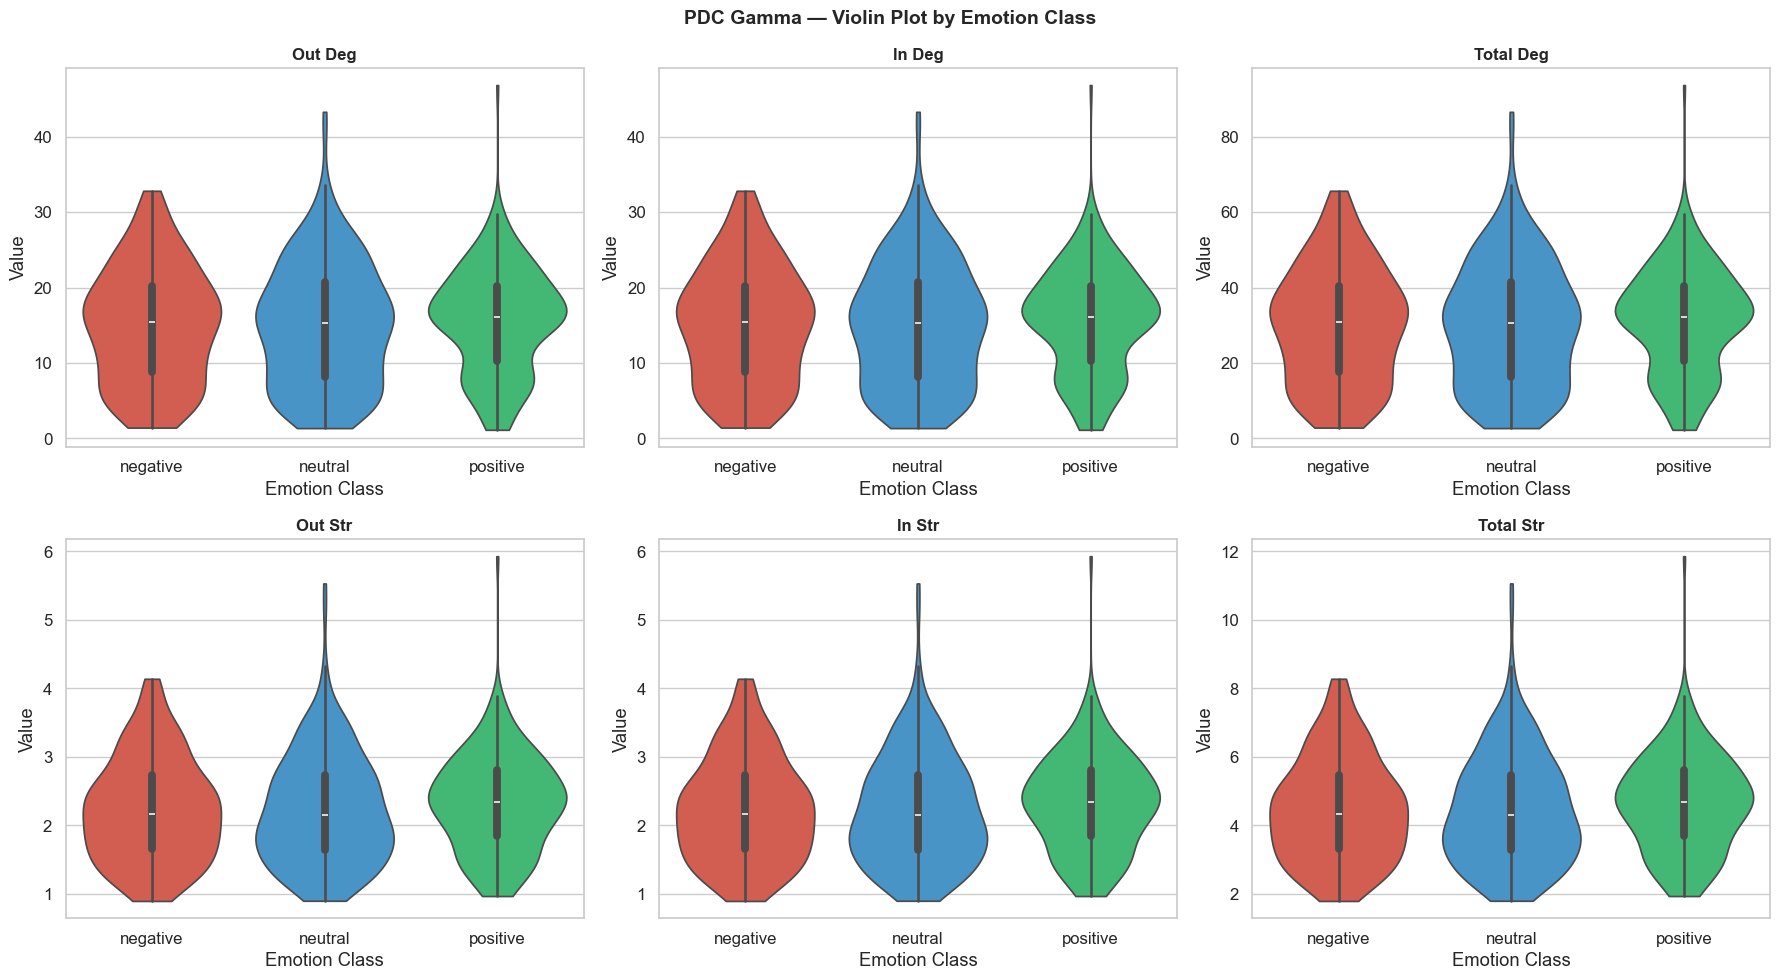


>>> PDC Broadband
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\pdc_broadband_violin.png


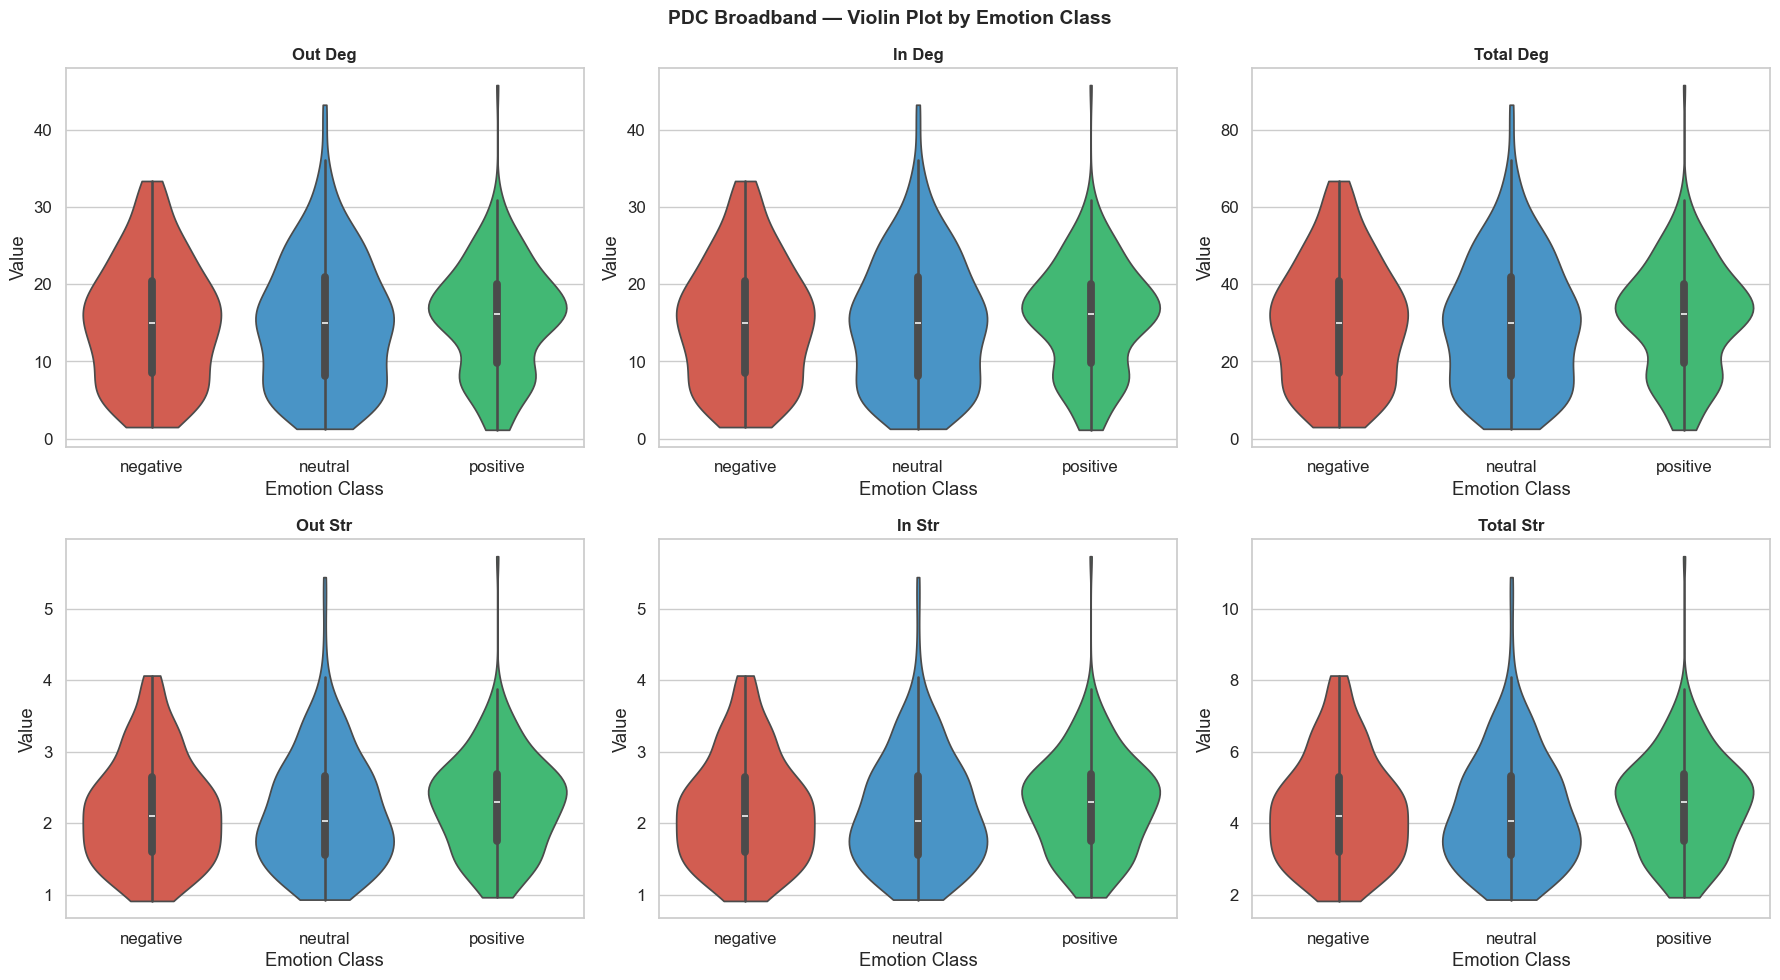

In [5]:
# ============================================================
# SEL INI: VIOLIN PLOT PER METRIK (6 subplot, 3 emosi)
# ------------------------------------------------------------
# Sel ini membuat violin plot yang menampilkan distribusi
# penuh data (densitas) + box plot dalam satu grafik.
# Berguna untuk melihat apakah distribusi unimodal/bimodal,
# simetris, atau condong (skewed) per kelas emosi.
#
# FIX: x=CLASS_COL ('class_label') bukan x='class' (numerik).
#      Sebelumnya x='class' mengakibatkan sumbu-X menampilkan
#      angka 0/1/2, order tidak cocok -> violin tidak muncul.
# Output: {method}_violin.png
# ============================================================
def plot_violinplots(df, method_name, save_prefix):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, col in enumerate(MEAN_COLS):
        ax = axes[idx]
        # FIX: x=CLASS_COL ('class_label') agar x-axis = teks emosi
        sns.violinplot(
            data=df, x=CLASS_COL, y=col, ax=ax,
            order=EMOTIONS, palette=PALETTE,
            inner='box', cut=0,
        )
        ax.set_title(SHORT[col], fontsize=12, fontweight='bold')
        ax.set_xlabel('Emotion Class')
        ax.set_ylabel('Value')
        ax.tick_params(axis='x', rotation=0)

    fig.suptitle(f'{method_name} — Violin Plot by Emotion Class',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    p = FIG_DIR / f'{save_prefix}_violin.png'
    fig.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {p}')
    plt.show()

for name, df in data.items():
    print(f'\n>>> {name}')
    plot_violinplots(df, name, name.lower().replace(' ', '_'))


---
## 5. Perbandingan Antar Semua Metode (Side-by-Side Box Plot)

Membandingkan distribusi **Total Strength** dari semua 7 metode
(GC + 6 band PDC) dalam satu gambar untuk melihat pola umum
dan perbedaan karakteristik antar metode.

Saved: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\figures\all_methods_total_strength_boxplot.png


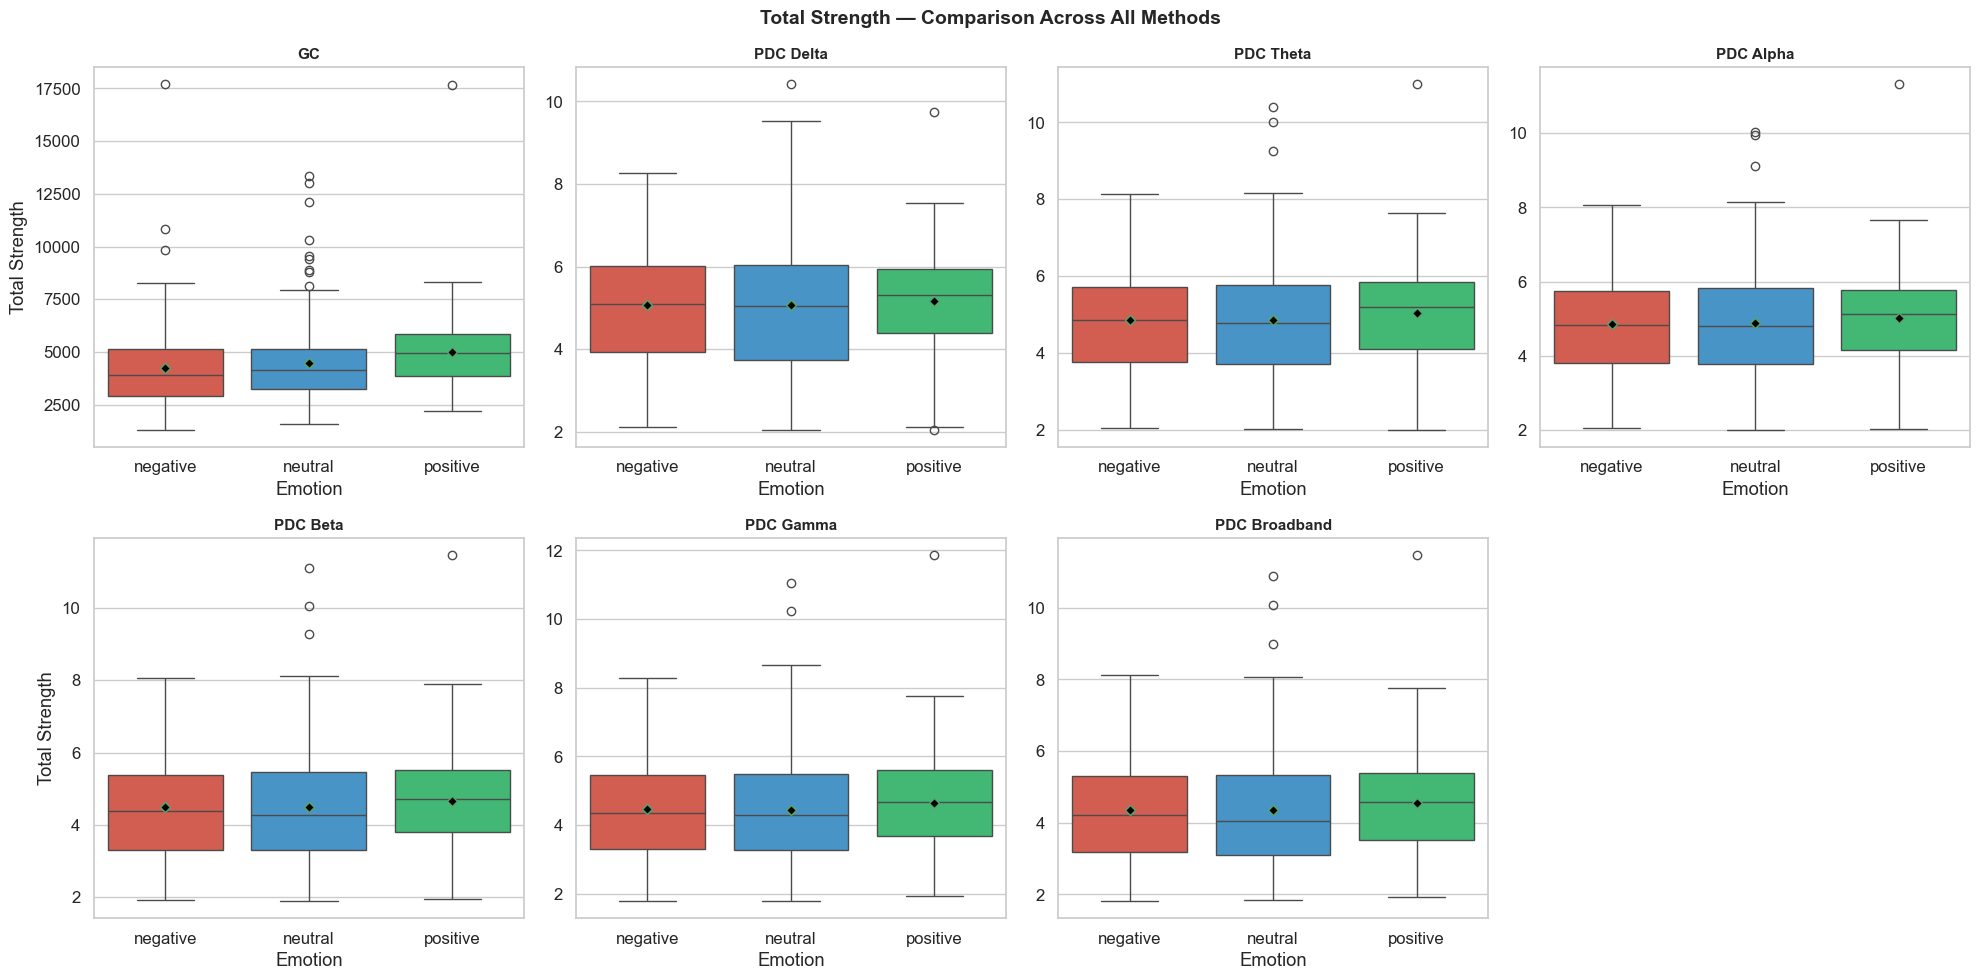

In [6]:
# ============================================================
# SEL INI: SIDE-BY-SIDE BOX PLOT — SEMUA METODE
# ------------------------------------------------------------
# Sel ini membuat satu gambar besar berisi box plot Total
# Strength dari semua metode (GC + 6 band PDC) berdampingan,
# sehingga pola perbedaan emosi bisa dibandingkan sekaligus.
#
# Setiap subplot = satu metode (GC / PDC Alpha / PDC Beta / dst.)
# Sumbu-X = 3 kelas emosi, Sumbu-Y = nilai Total Strength
#
# FIX: x=CLASS_COL ('class_label') bukan x='class' (numerik).
#      Juga diubah agar mendukung jumlah metode yang dinamis
#      (sebelumnya hard-coded 4 subplot, sekarang otomatis).
# Output: all_methods_total_strength_boxplot.png
# ============================================================
n_methods = len(data)
ncols = min(4, n_methods)        # maksimal 4 kolom per baris
nrows = (n_methods + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5), squeeze=False)
axes_flat = axes.flatten()

for idx, (name, df) in enumerate(data.items()):
    ax = axes_flat[idx]
    # FIX: x=CLASS_COL ('class_label') agar x-axis = teks emosi
    sns.boxplot(
        data=df, x=CLASS_COL, y='mean_total_strength', ax=ax,
        order=EMOTIONS, palette=PALETTE, showmeans=True,
        meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markersize': 8, 'markeredgecolor': 'black'},
    )
    ax.set_title(name, fontsize=32, fontweight='bold')
    ax.set_xlabel('Emotion', fontsize=26)
    ax.set_ylabel('Total Strength' if idx % ncols == 0 else '', fontsize=26)
    ax.tick_params(axis='both', labelsize=22)

# Sembunyikan subplot kosong jika ada
for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Total Strength — Comparison Across All Methods',
             fontsize=40, fontweight='bold')
plt.tight_layout()

p = FIG_DIR / 'all_methods_total_strength_boxplot.png'
fig.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {p}')
plt.show()


---
## 6. Ringkasan Akhir

In [7]:
# ============================================================
# SEL INI: RINGKASAN AKHIR PHASE 2.2
# ------------------------------------------------------------
# Sel ini menampilkan daftar lengkap semua file CSV dan gambar
# (PNG) yang berhasil dihasilkan selama eksekusi Phase 2.2,
# beserta ukuran file masing-masing.
#
# Gunakan output ini untuk:
#   - Memverifikasi semua file tersimpan dengan benar
#   - Melanjutkan ke Phase 2.3 (Inferential Statistics)
#   - Memasukkan tabel Mean±Std ke Bab 4 skripsi
# ============================================================
print('='*60)
print('PHASE 2.2 COMPLETE — Class Level Analysis')
print('='*60)

print(f'\nOutput CSV: {OUTPUT_DIR}')
for f in sorted(OUTPUT_DIR.glob('*.csv')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<50s}  ({size_kb:.1f} KB)')

print(f'\nFigures: {FIG_DIR}')
for f in sorted(FIG_DIR.glob('*.png')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<50s}  ({size_kb:.1f} KB)')

print(f'\nTotal datasets diproses: {len(data)}')
for name, df in data.items():
    print(f'  {name}: {df.shape[0]} baris, class_label: {sorted(df[CLASS_COL].unique())}')


PHASE 2.2 COMPLETE — Class Level Analysis

Output CSV: D:\Skripsi\new_data\phase_2_statistics\2.2_class_analysis\output
  descriptive_stats_gc.csv                            (1.8 KB)
  descriptive_stats_pdc_alpha.csv                     (1.7 KB)
  descriptive_stats_pdc_beta.csv                      (1.7 KB)
  descriptive_stats_pdc_broadband.csv                 (1.7 KB)
  descriptive_stats_pdc_delta.csv                     (1.7 KB)
  descriptive_stats_pdc_gamma.csv                     (1.7 KB)
  descriptive_stats_pdc_theta.csv                     (1.7 KB)
  summary_mean_std_gc.csv                             (0.8 KB)
  summary_mean_std_pdc_alpha.csv                      (0.8 KB)
  summary_mean_std_pdc_beta.csv                       (0.8 KB)
  summary_mean_std_pdc_broadband.csv                  (0.8 KB)
  summary_mean_std_pdc_delta.csv                      (0.7 KB)
  summary_mean_std_pdc_gamma.csv                      (0.8 KB)
  summary_mean_std_pdc_theta.csv                      (0.8 KB